# Marketplace Listing Integrity Agent

This notebook builds an agent that uses RAG and an LLM to decide whether a marketplace listing's image genuinely matches its text description.

### Agent Pipeline at a Glance

| Step | What happens | Uses an LLM? |
|---|---|---|
| 1. Build the RAG policy corpus | embed each category's policy into Chroma | No |
| 2. Detect category & product | ask the image what category and product it shows | No |
| 3. Extract description features | map the raw listing text onto the category's known schema | Yes |
| 4. Verify each feature | check OCR first, ask the image if it's not there | No |
| 5. Escalate anything still unclear | only runs when a feature stays ambiguous after Step 4 | Yes, rare |
| 6. Compute the verdict | flag the listing if any critical feature fails | No |

A listing usually needs exactly one LLM call, in Step 3. All six steps run as nodes on one LangGraph `StateGraph`, built in Step 5 below — a deterministic node is still a legitimate graph node, the same way it works in the sibling ridesharing project.

### Why extraction uses an LLM
Every other step in this pipeline is handled reliably by code. Extraction is different. A real listing arrives as plain text a seller wrote, like `"Prairie Farms Whole Milk, 1 Quart Carton"`. Turning that into structured fields needs real language understanding. Recognizing that `"8 oz"` describes the `size` slot, not `product_type`, isn't something a keyword rule can do reliably at marketplace scale.

> **Requires:** a local [Ollama](https://ollama.com) server running `qwen2.5:14b` and `nomic-embed-text` (embeddings). See the project README for setup.

## Setup

In [1]:
import sys
import os
import time
import inspect
sys.path.append(os.path.abspath(".."))

from langgraph.graph import StateGraph, START, END

from src.config import OLLAMA_MODEL, EMBED_MODEL
from src.policy_corpus import CATEGORY_POLICIES
from src.retrieval import build_policy_corpus, retrieve_category_policy, get_checklist_features, get_bounded_vocabulary
from src.extraction import extract_description_features
from src.tools import ALL_TOOLS
from src.vision_tools import detect_category_and_product
from src.listings import LISTINGS
from src.agent import (
    PipelineState,
    build_escalation_graph, make_escalate_node,
    detect_category_node, resolve_schema_node, extract_features_node,
    hard_stop_check_node, route_after_hard_stop,
    build_checklist_node, verify_features_node, route_after_verify,
    assemble_result_node,
    build_graph, verify_listing,
    _build_checklist, _deterministic_verify,
)

print(f"Reasoning model : {OLLAMA_MODEL}")
print(f"Embedding model : {EMBED_MODEL}")
print(f"LLM-facing tools (escalation): {[t.name for t in ALL_TOOLS]}")

Reasoning model : qwen2.5:7b
Embedding model : nomic-embed-text
LLM-facing tools (escalation): ['read_label_text', 'ask_vision_question']


---
## Step 1: Build the RAG Policy Corpus

Each category gets a policy document listing its critical and cosmetic features, embedded into Chroma. `retrieve_category_policy` looks this up by category name.

In [2]:
vectorstore = build_policy_corpus()
print(f"Collection size: {len(vectorstore.get()['ids'])} documents")

for category in ["grocery", "a pair of wireless bluetooth headphones", "a cotton crew-neck t-shirt"]:
    text = retrieve_category_policy(category)
    resolved = text.split("Category:")[1].split("(")[0].strip().rstrip(".")
    print(f"'{category}' -> {resolved}")

Collection size: 4 documents
'grocery' -> grocery
'a pair of wireless bluetooth headphones' -> electronics
'a cotton crew-neck t-shirt' -> apparel


---
## Step 2: Detect Category & Product

`detect_category_and_product` asks the image two questions: what category is this, and what specific product is it. It checks the two answers agree, and retries once if they don't.

In [3]:
listing = LISTINGS[0]
print(f"Listing: {listing['name']}\n")

t0 = time.time()
category, product, product_confirmed = detect_category_and_product(listing["image_url"])
print(f"category           : {category}")
print(f"product            : {product}")
print(f"product_confirmed  : {product_confirmed}")
print(f"(took {time.time() - t0:.1f}s)")

Listing: Prairie Farms Whole Milk — correct



`torch_dtype` is deprecated! Use `dtype` instead!


category           : this is a grocery item, specifically a carton of milk.
product            : milk
product_confirmed  : True
(took 10.0s)


---
## Step 3: Extract Description Features

`extract_description_features` maps the listing's raw text onto the category's known feature schema. Most fields are extracted as open text. `variant` and `container` are matched against a fixed list of known values instead.

This closed-list approach fixes a real problem. Asking the model to freely split `"Whole Milk"` into `product_type: "milk"` and `variant: "whole"` was unreliable. It either merged the two fields or dropped `variant` entirely, even with examples in the prompt. Giving it a list to pick from instead worked immediately.

In [4]:
critical_features, cosmetic_features = get_checklist_features(category)
bounded_vocab = get_bounded_vocabulary(category)
print(f"Known schema for '{category}': {critical_features + cosmetic_features}")
print(f"Bounded-vocabulary fields: {list(bounded_vocab.keys())}\n")

t0 = time.time()
description_features = extract_description_features(
    listing["description"], category, critical_features, cosmetic_features,
)
print(f"Raw text  : {listing['description']!r}")
print(f"Extracted : {description_features}")
print(f"(took {time.time() - t0:.1f}s)")

Known schema for 'this is a grocery item, specifically a carton of milk.': ['brand', 'product_type', 'size', 'variant', 'container']
Bounded-vocabulary fields: ['variant', 'container']

Raw text  : 'Prairie Farms Whole Milk, 1 Quart Carton'
Extracted : {'brand': 'Prairie Farms', 'product_type': 'Milk', 'size': '1 Quart', 'variant': 'whole', 'container': 'carton'}
(took 7.3s)


---
## Step 4: Verify Each Feature

For each feature: check the OCR text first. If it's not there, ask the image directly. Compare both against the claimed value using normalized string matching — the fix that removed the plural/singular and "misread OCR" bugs found during testing.

In [ ]:
checklist, checklist_critical = _build_checklist(critical_features, description_features)
print(f"Checklist: {checklist}\n")

t0 = time.time()
results, ambiguous = _deterministic_verify(listing["image_url"], checklist)
for feature, r in results.items():
    status = "match" if r["match"] is True else "mismatch" if r["match"] is False else "unconfirmed"
    print(f"  {feature:<10} [{r['source']:<3}] {status:<12} (claimed: '{r['value']}')")
print(f"\nAmbiguous (needs escalation): {ambiguous or 'none'}")
print(f"(took {time.time() - t0:.1f}s)")

---
## Step 5: Build the Full Pipeline Graph

Every step above — including the deterministic ones — is a node on one LangGraph `StateGraph`. This is what makes the whole agent one graph instead of a plain Python function with a small graph hidden inside it for escalation only.

### The state

Every node reads from and writes to the same shared state — a `TypedDict` that fixes exactly what fields exist. Here's this pipeline's:

In [5]:
print(inspect.getsource(PipelineState))

class PipelineState(TypedDict):
    # inputs
    image_url: str
    raw_description: str
    # set by detect_category_node
    raw_category: str          # the raw VQA answer, e.g. "this is a grocery item..."
    product: str
    product_confirmed: bool
    display_category: str      # resolved, clean category name (e.g. "grocery")
    # set by resolve_schema_node
    critical_features: list[str]
    cosmetic_features: list[str]
    # set by extract_features_node
    description_features: dict
    # set by hard_stop_check_node
    hard_stop: bool
    # set by build_checklist_node
    checklist: dict
    checklist_critical: list[str]
    # set by verify_features_node / escalate_node
    results: dict
    ambiguous: list[str]
    escalated: bool
    # set by assemble_result_node
    verdict: str
    category: str
    critical_checked: dict
    other_checked: dict
    answer: str
    ambiguous_features: list[str]



### The graph

```
detect_category
      |
resolve_schema
      |
extract_features
      |
hard_stop_check
      | (conditional edge)
 -----+------------------
 |                       |
 v continue              v hard stop
build_checklist          |
      |                  |
verify_features          |
      | (conditional edge)
 -----+------------      |
 |                  |     |
 v resolved         v ambiguous
 |               escalate |
 -----+------------+------
      |
assemble_result
      |
     END
```

Two conditional edges decide the path. `hard_stop_check` skips straight to the verdict if the image and description disagree on the product entirely. `verify_features` only routes through `escalate` if a feature stayed ambiguous after OCR/VQA. Every other edge is fixed.

### Building it

Register each node under a name, connect them with `add_edge`, and use `add_conditional_edges` for the two places the next step depends on the state. The escalation sub-graph is compiled once and wrapped as a single node — `make_escalate_node` closes over it so the node doesn't rebuild it on every call.

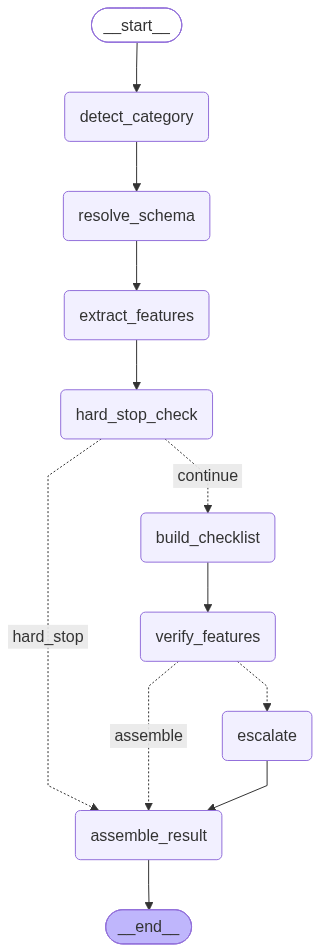

In [6]:
escalation_graph = build_escalation_graph()
escalate_node = make_escalate_node(escalation_graph)

g = StateGraph(PipelineState)
g.add_node("detect_category", detect_category_node)
g.add_node("resolve_schema", resolve_schema_node)
g.add_node("extract_features", extract_features_node)
g.add_node("hard_stop_check", hard_stop_check_node)
g.add_node("build_checklist", build_checklist_node)
g.add_node("verify_features", verify_features_node)
g.add_node("escalate", escalate_node)
g.add_node("assemble_result", assemble_result_node)

g.add_edge(START, "detect_category")
g.add_edge("detect_category", "resolve_schema")
g.add_edge("resolve_schema", "extract_features")
g.add_edge("extract_features", "hard_stop_check")

# A conditional edge picks the next node at runtime, based on a function's
# return value -- route_after_hard_stop reads state["hard_stop"] and returns
# which branch to take.
g.add_conditional_edges("hard_stop_check", route_after_hard_stop, {
    "hard_stop": "assemble_result",
    "continue": "build_checklist",
})

g.add_edge("build_checklist", "verify_features")

g.add_conditional_edges("verify_features", route_after_verify, {
    "escalate": "escalate",
    "assemble": "assemble_result",
})

g.add_edge("escalate", "assemble_result")
g.add_edge("assemble_result", END)

graph = g.compile()

try:
    from IPython.display import Image, display
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    print("Diagram rendering unavailable, printing graph structure instead:")
    print(graph.get_graph().draw_mermaid())

---
## Step 6: Run the Full Pipeline

Now the whole thing runs end to end, across all 5 listings: one correct case, three injected mismatches (wrong brand, wrong size, wrong product), and one more correct listing as a control. Watch the `escalated` field: most listings should only need the one extraction call.

In [7]:
for listing in LISTINGS:
    print(f"Listing: {listing['name']}")
    print(f"Description: {listing['description']!r}")
    t0 = time.time()
    result = verify_listing(graph, listing["image_url"], listing["description"])
    elapsed = time.time() - t0

    print(f"  extracted   : {result['description_features']}")
    print(f"  category    : {result['category']}")
    print(f"  hard_stop   : {result['hard_stop']}")
    print(f"  escalated   : {result['escalated']}  (ambiguous features: {result['ambiguous_features'] or 'none'})")
    print(f"  took        : {elapsed:.1f}s")
    print()
    print(result["answer"])
    print("\n" + "=" * 70 + "\n")

Listing: Prairie Farms Whole Milk — correct
Description: 'Prairie Farms Whole Milk, 1 Quart Carton'


/opt/anaconda3/envs/listing-integrity-agent/lib/python3.11/site-packages/torch/ao/nn/quantized/dynamic/modules/rnn.py:162: UserWarning: torch.quantize_per_tensor, torch.quantize_per_channel and other quantized tensor creation functions that produce tensors with dtype torch.quint8, torch.qint8, and torch.qint32 are deprecated and will be removed in a future PyTorch release. Please see https://github.com/pytorch/pytorch/issues/184982 for more information. (Triggered internally at /Users/runner/miniforge3/conda-bld/libtorch_1786372171945/work/aten/src/ATen/quantized/Quantizer.cpp:116.)
  w_ih = torch.quantize_per_tensor(
/opt/anaconda3/envs/listing-integrity-agent/lib/python3.11/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


  extracted   : {'brand': 'Prairie Farms', 'product_type': 'Milk', 'size': '1 Quart', 'variant': 'whole', 'container': 'carton'}
  category    : grocery
  hard_stop   : False
  escalated   : False  (ambiguous features: none)
  took        : 14.2s

Verdict: Likely match
Category: grocery
Critical features checked: brand: match, size: match, variant: match, container: match, product_type: match
Other claims checked: None
Reasoning: All checked critical features matched the description.


Listing: Prairie Farms Milk — wrong brand
Description: 'Organic Valley Whole Milk, 1 Quart Carton'


/opt/anaconda3/envs/listing-integrity-agent/lib/python3.11/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


  extracted   : {'brand': 'Organic Valley', 'product_type': 'Milk', 'size': '1 Quart', 'variant': 'whole', 'container': 'carton'}
  category    : grocery
  hard_stop   : False
  escalated   : False  (ambiguous features: none)
  took        : 6.3s

Verdict: Likely mismatch
Category: grocery
Critical features checked: brand: mismatch, size: match, variant: match, container: match, product_type: match
Other claims checked: None
Reasoning: Critical feature mismatch on: brand (claimed 'Organic Valley'). This alone is enough to flag the listing.


Listing: Amazon Fresh Chicken Breast — correct
Description: 'Amazon Fresh Boneless Skinless Chicken Breast, 30 oz Plastic Container'


/opt/anaconda3/envs/listing-integrity-agent/lib/python3.11/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


  extracted   : {'brand': 'Amazon Fresh', 'product_type': 'Chicken Breast', 'size': '30 oz', 'variant': 'boneless skinless', 'container': 'container'}
  category    : grocery
  hard_stop   : False
  escalated   : False  (ambiguous features: none)
  took        : 30.7s

Verdict: Likely match
Category: grocery
Critical features checked: brand: match, size: match, variant: match, container: match, product_type: match
Other claims checked: None
Reasoning: All checked critical features matched the description.


Listing: Land O Lakes Salted Butter — wrong size
Description: 'Land O Lakes Salted Butter, 16 oz Paper Box'


/opt/anaconda3/envs/listing-integrity-agent/lib/python3.11/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


  extracted   : {'brand': 'Land O Lakes', 'product_type': 'Butter', 'size': '16 oz', 'variant': 'salted', 'container': 'box'}
  category    : grocery
  hard_stop   : False
  escalated   : False  (ambiguous features: none)
  took        : 12.4s

Verdict: Likely mismatch
Category: grocery
Critical features checked: brand: match, size: mismatch, variant: match, container: match, product_type: match
Other claims checked: None
Reasoning: Critical feature mismatch on: size (claimed '16 oz'). This alone is enough to flag the listing.


Listing: Prairie Farms Milk photo — described as juice (wrong product)
Description: 'Tropicana Orange Juice, 1 Quart Carton'
  extracted   : {'brand': 'Tropicana', 'product_type': 'Orange Juice', 'size': '1 Quart', 'container': 'carton'}
  category    : grocery
  hard_stop   : True
  escalated   : False  (ambiguous features: none)
  took        : 5.8s

Verdict: Likely mismatch
Category: grocery
Critical features checked: product_type: mismatch
Other claims chec

---
## Summary

### What this agent does
- Detects category and product directly from the image, before trusting anything the description claims
- Extracts structured features from the listing's raw text with one LLM call
- Retrieves the category's policy from a RAG corpus to know which features are critical
- Verifies each feature against the image: OCR first, a targeted question as fallback
- Escalates to a small LangGraph loop only when a feature stays genuinely ambiguous
- Computes the final verdict from code: any critical mismatch flags the listing

### Key findings
- A wrong-brand listing used to slip through as "Likely match" because a model sometimes skipped checking and guessed instead. Making OCR-then-image-check unconditional code fixed this
- A plural/singular mismatch ("chicken breast" vs. "chicken breasts") is fixed by normalizing values before comparing, not by a prompt rule a smaller model could ignore
- Extraction took three iterations to get right. A bare schema extracted only 2 of 5 fields. Adding field descriptions changed nothing. Adding examples got 4 of 5. The last gap ("Whole Milk" not splitting into product_type + variant) was fixed by giving `variant` a fixed list to pick from instead of open text
- How often escalation fires is itself a useful signal. A category that escalates a lot means its known feature list needs work

### Limitations
- The category/product consistency check has no escalation path. A genuinely unclear disagreement is resolved by a fixed rule, not investigated further
- Bounded-vocabulary lists (`variant`, `container`) only exist for grocery. Electronics and apparel would extract any similar field as open text, untested
- Extraction is only validated on grocery listings
- No human-in-the-loop yet. Every verdict is fully automatic

### Potential future work
- Bounded vocabularies for electronics/apparel's own bounded-ish fields (e.g. `color`)
- Measure escalation rate across a larger, more varied test set
- A human-in-the-loop gate before a "Likely mismatch" verdict executes, for high-risk categories or sellers
- Real verified images for electronics and apparel to close the live-testing gap